# Modelagem Preditiva

**Projeto:** Assinaturas preditivas dos tipos de violência contra a mulher  
**Autora:** Rafaela Lucca

## Setup

In [1]:
# === CONFIGURAÇÃO ===
# Ajuste este caminho para o diretório do projeto no seu ambiente.
# No Google Colab, normalmente fica dentro do Google Drive montado.
PROJECT_PATH = '/content/drive/MyDrive/projeto_violencia_mulher'


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install xgboost lightgbm scikit-learn scipy statsmodels --quiet

In [4]:
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import load_npz
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

DRIVE = Path(PROJECT_PATH)
RESULTADOS = DRIVE / 'resultados_cientificos'
RESULTADOS.mkdir(exist_ok=True)

RANDOM_STATE = 42

ALVOS = ['y_fisic', 'y_psico', 'y_sexu']
NOMES = {'y_fisic': 'Violência Física',
         'y_psico': 'Violência Psicológica',
         'y_sexu':  'Violência Sexual'}
print('Ambiente configurado.')

Ambiente configurado.


## 1. Análise pré-modelagem

Desbalanceamento dos desfechos, associações bivariadas e multicolinearidade antes de treinar os modelos.

In [5]:
# Carrega dados processados
X_train = load_npz(DRIVE / 'X_train.npz')
X_test  = load_npz(DRIVE / 'X_test.npz')
y_train = pd.read_parquet(DRIVE / 'y_train.parquet')
y_test  = pd.read_parquet(DRIVE / 'y_test.parquet')

with open(DRIVE / 'feature_names.json') as f:
    feature_names = json.load(f)

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Features após One-Hot: {len(feature_names)}')

X_train: (2556340, 275)
X_test:  (875656, 275)
Features após One-Hot: 275


### 1.1 Prevalência dos desfechos

In [6]:
print('PREVALÊNCIA DOS DESFECHOS\n' + '='*60)
prevalencias = {}
for alvo in ALVOS:
    y = y_train[alvo].dropna()
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    prev = n_pos / (n_pos + n_neg)
    razao = n_neg / n_pos
    prevalencias[alvo] = prev

    print(f'\n{NOMES[alvo]}:')
    print(f'  Positivos: {n_pos:>9,}  |  Negativos: {n_neg:>9,}')
    print(f'  Prevalência: {prev:.3f} ({100*prev:.1f}%)')
    print(f'  Razão neg:pos = {razao:.2f}:1')

    # Interpretação
    if prev > 0.40:
        nivel = 'BAIXO — classes aproximadamente equilibradas'
    elif prev > 0.20:
        nivel = 'MODERADO — atenção a precisão e recall'
    else:
        nivel = 'ACENTUADO — priorizar PR-AUC e balanced accuracy'
    print(f'  Desbalanceamento: {nivel}')

print('\n' + '='*60)
print('IMPLICAÇÃO METODOLÓGICA:')
print('A acurácia será reportada, mas NÃO será métrica primária —')
print('em desfechos desbalanceados ela é inflada pela classe majoritária.')

PREVALÊNCIA DOS DESFECHOS

Violência Física:
  Positivos: 1,297,334  |  Negativos: 1,227,053
  Prevalência: 0.514 (51.4%)
  Razão neg:pos = 0.95:1
  Desbalanceamento: BAIXO — classes aproximadamente equilibradas

Violência Psicológica:
  Positivos:   594,232  |  Negativos: 1,899,778
  Prevalência: 0.238 (23.8%)
  Razão neg:pos = 3.20:1
  Desbalanceamento: MODERADO — atenção a precisão e recall

Violência Sexual:
  Positivos:   402,440  |  Negativos: 2,089,678
  Prevalência: 0.161 (16.1%)
  Razão neg:pos = 5.19:1
  Desbalanceamento: ACENTUADO — priorizar PR-AUC e balanced accuracy

IMPLICAÇÃO METODOLÓGICA:
A acurácia será reportada, mas NÃO será métrica primária —
em desfechos desbalanceados ela é inflada pela classe majoritária.


### 1.2 Associação bivariada

Qui-quadrado e V de Cramér entre cada preditor e o desfecho. O V de Cramér mede a força da associação — com amostras grandes o qui-quadrado é quase sempre significante, então é ele que indica relevância prática.

In [7]:
def cramers_v(chi2, n, r, k):
    """V de Cramér com correção de viés (Bergsma 2013)."""
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    return np.sqrt(phi2corr / denom) if denom > 0 else 0.0

def analise_bivariada(alvo, top_n=25):
    """Testa associação de cada feature com o desfecho."""
    mask = y_train[alvo].notna()
    y = y_train.loc[mask, alvo].astype(int).values
    X = X_train[mask.values]
    n = len(y)

    resultados = []
    for j, fname in enumerate(feature_names):
        coluna = np.asarray(X[:, j].todense()).ravel()
        # Binariza a feature (One-Hot já é 0/1; idade padronizada tratamos à parte)
        if set(np.unique(coluna)) <= {0.0, 1.0}:
            # Tabela de contingência 2x2
            tab = pd.crosstab(coluna, y)
            if tab.shape == (2, 2) and tab.values.min() >= 5:
                chi2, p, dof, _ = stats.chi2_contingency(tab)
                v = cramers_v(chi2, n, 2, 2)
                resultados.append({'feature': fname, 'chi2': chi2,
                                   'p_valor': p, 'cramers_v': v})

    df = pd.DataFrame(resultados).sort_values('cramers_v', ascending=False)
    return df.reset_index(drop=True)

# Roda para os 3 alvos
bivariada = {}
for alvo in ALVOS:
    print(f'Analisando {NOMES[alvo]}...')
    bivariada[alvo] = analise_bivariada(alvo)
    print(f'  {len(bivariada[alvo])} variáveis binárias testadas')

print('\n✓ Análise bivariada concluída.')

Analisando Violência Física...
  271 variáveis binárias testadas
Analisando Violência Psicológica...
  271 variáveis binárias testadas
Analisando Violência Sexual...
  269 variáveis binárias testadas

✓ Análise bivariada concluída.


In [8]:
# Exibe top 20 associações por alvo
for alvo in ALVOS:
    print(f'\n{"="*65}')
    print(f'TOP 20 ASSOCIAÇÕES — {NOMES[alvo]}')
    print(f'{"="*65}')
    df = bivariada[alvo].head(20).copy()
    df['feature_curta'] = df['feature'].apply(
        lambda x: x.replace('cat__','').replace('num__','')[:42])
    df['significancia'] = df['p_valor'].apply(
        lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

    for _, r in df.iterrows():
        # Classifica a força do V de Cramér
        v = r['cramers_v']
        if v >= 0.25:   forca = 'forte'
        elif v >= 0.15: forca = 'moderada'
        elif v >= 0.10: forca = 'fraca'
        else:           forca = 'desprezível'
        print(f'  {r["feature_curta"]:44} V={v:.3f} ({forca:11}) {r["significancia"]}')

    bivariada[alvo].to_csv(RESULTADOS / f'bivariada_{alvo}.csv', index=False)

print('\n\nNOTA INTERPRETATIVA:')
print('V de Cramér: <0.10 desprezível | 0.10-0.15 fraca | 0.15-0.25 moderada | >0.25 forte')
print('Associações com V desprezível, ainda que significantes (***), têm')
print('pouca relevância prática — efeito do tamanho amostral, não do fenômeno.')


TOP 20 ASSOCIAÇÕES — Violência Física
  AG_FORCA_1                                   V=0.648 (forte      ) ***
  AG_FORCA_2                                   V=0.632 (forte      ) ***
  LES_AUTOP_1                                  V=0.361 (forte      ) ***
  AG_ENVEN_1                                   V=0.340 (forte      ) ***
  LES_AUTOP_2                                  V=0.334 (forte      ) ***
  REL_CONJ_2                                   V=0.317 (forte      ) ***
  AG_ENVEN_2                                   V=0.310 (forte      ) ***
  REL_CONJ_1                                   V=0.298 (forte      ) ***
  AUTOR_SEXO_2                                 V=0.291 (forte      ) ***
  AUTOR_SEXO_1                                 V=0.278 (forte      ) ***
  REL_PROPRI_1                                 V=0.249 (moderada   ) ***
  AG_OUTROS_1                                  V=0.223 (moderada   ) ***
  SIT_CONJUG_8                                 V=0.214 (moderada   ) ***
  AUTOR_ALCO

### 1.3 Assinaturas bivariadas por tipo

As variáveis mais associadas a cada desfecho são as mesmas ou diferentes?

In [9]:
# Top 15 de cada alvo, por V de Cramér
TOP_K = 15
tops = {alvo: set(bivariada[alvo].head(TOP_K)['feature']) for alvo in ALVOS}

universais = tops['y_fisic'] & tops['y_psico'] & tops['y_sexu']
print(f'Variáveis no top {TOP_K} dos TRÊS desfechos (universais): {len(universais)}')
for f in sorted(universais):
    print(f'  · {f.replace("cat__","").replace("num__","")[:50]}')

for alvo in ALVOS:
    exclusivas = tops[alvo] - set().union(*[tops[a] for a in ALVOS if a != alvo])
    print(f'\nExclusivas de {NOMES[alvo]} (top {TOP_K}): {len(exclusivas)}')
    for f in sorted(exclusivas):
        print(f'  · {f.replace("cat__","").replace("num__","")[:50]}')

print('\n\nLEITURA EXPLORATÓRIA:')
print('Se houver poucas variáveis universais e muitas exclusivas, há')
print('evidência preliminar (pré-modelagem) a favor de H1.')

Variáveis no top 15 dos TRÊS desfechos (universais): 6
  · AG_ENVEN_1
  · AUTOR_SEXO_1
  · AUTOR_SEXO_2
  · LES_AUTOP_1
  · LES_AUTOP_2
  · REL_PROPRI_1

Exclusivas de Violência Física (top 15): 3
  · AG_OUTROS_1
  · AUTOR_ALCO_1
  · REL_CONJ_2

Exclusivas de Violência Psicológica (top 15): 4
  · AG_AMEACA_1
  · AG_AMEACA_2
  · OUT_VEZES_1
  · REL_EXCON_1

Exclusivas de Violência Sexual (top 15): 8
  · CS_ESCOL_N_10
  · CS_GESTANT_6
  · ORIENT_SEX_8
  · REL_CONHEC_1
  · REL_CONHEC_2
  · REL_DESCO_1
  · REL_DESCO_2
  · REL_PAD_1


LEITURA EXPLORATÓRIA:
Se houver poucas variáveis universais e muitas exclusivas, há
evidência preliminar (pré-modelagem) a favor de H1.


### 1.4 Multicolinearidade

Colunas muito correlacionadas desestabilizam os coeficientes da Logística. Detectamos pares com correlação alta.

In [10]:
from scipy.sparse import csc_matrix

# Amostra para o cálculo de correlação (eficiência)
np.random.seed(RANDOM_STATE)
idx_amostra = np.random.choice(X_train.shape[0], size=50_000, replace=False)
X_amostra = X_train[idx_amostra].tocsc()

# Identifica features com variância não-nula
variancias = np.asarray((X_amostra.power(2)).mean(axis=0)).ravel() - \
             np.asarray(X_amostra.mean(axis=0)).ravel()**2
features_validas = np.where(variancias > 1e-6)[0]
print(f'Features com variância não-desprezível: {len(features_validas)} de {len(feature_names)}')

# Correlação par-a-par só nas features válidas
X_dense = np.asarray(X_amostra[:, features_validas].todense())
corr = np.corrcoef(X_dense, rowvar=False)
np.fill_diagonal(corr, 0)

# Pares com |correlação| > 0.8
pares_altos = []
for i in range(len(features_validas)):
    for j in range(i+1, len(features_validas)):
        if abs(corr[i,j]) > 0.8:
            pares_altos.append({
                'feature_1': feature_names[features_validas[i]],
                'feature_2': feature_names[features_validas[j]],
                'correlacao': corr[i,j]
            })

print(f'\nPares de features com |correlação| > 0.8: {len(pares_altos)}')
if pares_altos:
    print('\nATENÇÃO — redundância detectada:')
    for p in sorted(pares_altos, key=lambda x: -abs(x['correlacao']))[:15]:
        f1 = p['feature_1'].replace('cat__','').replace('num__','')[:32]
        f2 = p['feature_2'].replace('cat__','').replace('num__','')[:32]
        print(f'  r={p["correlacao"]:+.3f}  {f1}  <->  {f2}')
    print('\nINTERPRETAÇÃO: estes pares carregam informação redundante.')
    print('Os coeficientes da Logística para essas variáveis devem ser')
    print('lidos com cautela. Modelos de árvore não são afetados.')
else:
    print('Nenhuma redundância grave. Coeficientes podem ser interpretados')
    print('com segurança quanto a multicolinearidade.')

del X_dense, corr
gc.collect()

Features com variância não-desprezível: 271 de 275

Pares de features com |correlação| > 0.8: 643

ATENÇÃO — redundância detectada:
  r=+1.000  DEF_VISUAL_MISSING  <->  DEF_AUDITI_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  TRAN_MENT_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  TRAN_COMP_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  DEF_OUT_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  NUM_ENVOLV_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_PAD_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_MAD_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_TRAB_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_CAT_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_INST_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_POL_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_PROPRI_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  REL_OUTROS_MISSING
  r=+1.000  DEF_VISUAL_MISSING  <->  TPUNINOT_  
  r=-1.000  DEF_VISUAL_MISSING  <->  TPUNINOT_MISSING

INTERPRETAÇÃO: estes pares carregam informação redundante

0

### 1.5 Deduplicação de colunas

As flags `_MISSING` do One-Hot são redundantes quando blocos inteiros da ficha são preenchidos juntos. Agrupamos colunas redundantes (correlação ≥ 0,95) e mantemos um representante de cada grupo.

In [11]:
from scipy.sparse import csc_matrix

def deduplica_colunas(X, nomes, limiar=0.95, n_amostra=50_000):
    """Identifica grupos de colunas redundantes (|corr| >= limiar) e
    retorna os índices a MANTER (um representante por grupo).
    O representante escolhido é o de maior variância — mais informativo."""
    np.random.seed(RANDOM_STATE)
    idx = np.random.choice(X.shape[0], size=min(n_amostra, X.shape[0]), replace=False)
    Xs = X[idx].tocsc()

    # Variância de cada coluna
    var = np.asarray((Xs.power(2)).mean(axis=0)).ravel() - \
          np.asarray(Xs.mean(axis=0)).ravel()**2
    validas = np.where(var > 1e-6)[0]

    # Matriz de correlação entre as colunas com variância
    Xd = np.asarray(Xs[:, validas].todense())
    corr = np.corrcoef(Xd, rowvar=False)
    corr = np.nan_to_num(corr)

    # Agrupa colunas redundantes via componentes conexas
    n = len(validas)
    grupo = list(range(n))  # union-find simples
    def find(x):
        while grupo[x] != x:
            grupo[x] = grupo[grupo[x]]
            x = grupo[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            grupo[max(ra,rb)] = min(ra,rb)

    for i in range(n):
        for j in range(i+1, n):
            if abs(corr[i,j]) >= limiar:
                union(i, j)

    # Para cada grupo, mantém a coluna de maior variância
    from collections import defaultdict
    grupos = defaultdict(list)
    for i in range(n):
        grupos[find(i)].append(i)

    manter_local = []
    grupos_redundantes = 0
    for membros in grupos.values():
        if len(membros) > 1:
            grupos_redundantes += 1
        # representante = maior variância
        melhor = max(membros, key=lambda m: var[validas[m]])
        manter_local.append(melhor)

    # Índices globais a manter: representantes + colunas sem variância removidas
    idx_manter = sorted([validas[m] for m in manter_local])

    return idx_manter, grupos, validas, grupos_redundantes

idx_manter, grupos, validas, n_grupos_red = deduplica_colunas(X_train, feature_names)

print(f'Colunas originais:        {len(feature_names)}')
print(f'Colunas com variância:    {len(validas)}')
print(f'Grupos de redundância:    {n_grupos_red}')
print(f'Colunas após deduplicação: {len(idx_manter)}')
print(f'Colunas removidas:        {len(feature_names) - len(idx_manter)}')

Colunas originais:        275
Colunas com variância:    271
Grupos de redundância:    14
Colunas após deduplicação: 211
Colunas removidas:        64


In [12]:
# Mostra exemplos de grupos redundantes identificados
print('EXEMPLOS DE GRUPOS DE COLUNAS REDUNDANTES TRATADOS\n' + '='*60)
mostrados = 0
for membros in grupos.values():
    if len(membros) > 1 and mostrados < 8:
        nomes_grupo = [feature_names[validas[m]] for m in membros]
        print(f'\nGrupo de {len(membros)} colunas redundantes:')
        for nm in nomes_grupo[:6]:
            print(f'  · {nm}')
        if len(nomes_grupo) > 6:
            print(f'  ... e mais {len(nomes_grupo)-6}')
        mostrados += 1

print('\n' + '='*60)
print('INTERPRETAÇÃO: cada grupo acima foi reduzido a uma única coluna')
print('representante. A informação é preservada (a coluna mantida carrega')
print('o mesmo sinal); elimina-se apenas a duplicação que desestabiliza')
print('os coeficientes da Regressão Logística.')

EXEMPLOS DE GRUPOS DE COLUNAS REDUNDANTES TRATADOS

Grupo de 18 colunas redundantes:
  · cat__SG_UF_OCOR_IGNORADO
  · cat__DEF_VISUAL_MISSING
  · cat__DEF_AUDITI_MISSING
  · cat__TRAN_MENT_MISSING
  · cat__TRAN_COMP_MISSING
  · cat__DEF_OUT_MISSING
  ... e mais 12

Grupo de 2 colunas redundantes:
  · cat__IDENT_GEN_8
  · cat__IDENT_GEN_9

Grupo de 2 colunas redundantes:
  · cat__DEF_FISICA_ 
  · cat__DEF_MENTAL_ 

Grupo de 2 colunas redundantes:
  · cat__DEF_FISICA_8
  · cat__DEF_MENTAL_8

Grupo de 2 colunas redundantes:
  · cat__DEF_VISUAL_ 
  · cat__DEF_AUDITI_ 

Grupo de 2 colunas redundantes:
  · cat__DEF_VISUAL_2
  · cat__DEF_AUDITI_2

Grupo de 5 colunas redundantes:
  · cat__DEF_VISUAL_8
  · cat__DEF_AUDITI_8
  · cat__TRAN_MENT_8
  · cat__TRAN_COMP_8
  · cat__DEF_OUT_8

Grupo de 2 colunas redundantes:
  · cat__DEF_VISUAL_9
  · cat__DEF_AUDITI_9

INTERPRETAÇÃO: cada grupo acima foi reduzido a uma única coluna
representante. A informação é preservada (a coluna mantida carrega
o mes

In [ ]:
# Aplica a deduplicação a X_train, X_test e feature_names
X_train = X_train[:, idx_manter]
X_test  = X_test[:, idx_manter]
feature_names = [feature_names[i] for i in idx_manter]

print(f'Matrizes após deduplicação:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test:  {X_test.shape}')
print(f'  feature_names: {len(feature_names)}')
print('\nA partir daqui, todos os modelos usam o conjunto deduplicado.')
gc.collect()

## 2. Regressão Logística

Modelo de referência interpretável: coeficientes dão direção e magnitude dos efeitos, com intervalos de confiança para inferência.

In [13]:
from sklearn.model_selection import train_test_split

TAMANHO_AMOSTRA = 500_000

mask_validos = y_train.notna().all(axis=1)
y_combo = (y_train.loc[mask_validos,'y_fisic'].astype(int).astype(str) +
           y_train.loc[mask_validos,'y_psico'].astype(int).astype(str) +
           y_train.loc[mask_validos,'y_sexu'].astype(int).astype(str))

X_val = X_train[mask_validos.values]
y_val = y_train.loc[mask_validos].reset_index(drop=True)

idx_am, _ = train_test_split(np.arange(len(y_val)),
                             train_size=TAMANHO_AMOSTRA,
                             stratify=y_combo, random_state=RANDOM_STATE)

X_am = X_val[idx_am]
y_am = y_val.iloc[idx_am].reset_index(drop=True)

del X_val, y_val, y_combo
gc.collect()
print(f'Amostra de treino: {X_am.shape}')
for alvo in ALVOS:
    print(f'  {alvo}: prevalência {100*(y_am[alvo]==1).mean():.1f}%')

Amostra de treino: (500000, 275)
  y_fisic: prevalência 50.8%
  y_psico: prevalência 23.4%
  y_sexu: prevalência 15.8%


### 2.2 Treino com e sem balanceamento

Duas versões de cada modelo. O `class_weight='balanced'` melhora o recall mas afeta a calibração — comparar as duas é um resultado.

### Regularização: L1, L2 e Elastic Net

Comparamos os três esquemas de penalização. Alternativa à seleção stepwise, cujos intervalos de confiança são invalidados pelo processo de seleção sequencial.

In [14]:
from sklearn.linear_model import LogisticRegression

# Três esquemas de regularização comparados:
#  L2 (Ridge)   — encolhe coeficientes, não zera; default do sklearn
#  L1 (Lasso)   — zera coeficientes irrelevantes; faz seleção de variáveis
#  ElasticNet   — combina L1+L2; bom com grupos de variáveis correlacionadas
REGULARIZACOES = {
    'L2':         dict(penalty='l2', solver='saga'),
    'L1':         dict(penalty='l1', solver='saga'),
    'ElasticNet': dict(penalty='elasticnet', solver='saga', l1_ratio=0.5),
}

def treina_logistica(alvo, balanceado, reg='L2'):
    """Treina Regressão Logística com o esquema de regularização indicado."""
    mask = y_am[alvo].notna()
    Xtr = X_am[mask.values]
    ytr = y_am.loc[mask, alvo].astype(int)

    params = REGULARIZACOES[reg]
    modelo = LogisticRegression(
        C=1.0,
        max_iter=3000,          # saga converge mais devagar
        class_weight=('balanced' if balanceado else None),
        random_state=RANDOM_STATE, n_jobs=-1,
        **params
    )
    modelo.fit(Xtr, ytr)
    return modelo

# Treina: 3 alvos x 3 regularizações (versão SEM balanceamento, p/ interpretação)
log_models = {}
for alvo in ALVOS:
    for reg in REGULARIZACOES:
        print(f'Treinando Logística — {alvo} — regularização={reg}...')
        log_models[(alvo, reg)] = treina_logistica(alvo, balanceado=False, reg=reg)

# Também treina a versão balanceada do melhor esquema (definido adiante) —
# por ora, guardamos a balanceada de L2 para a análise de calibração
for alvo in ALVOS:
    log_models[(alvo, 'L2_bal')] = treina_logistica(alvo, balanceado=True, reg='L2')

print(f'\n✓ {len(log_models)} modelos logísticos treinados (3 alvos x 3 regularizações + balanceados).')

Treinando Logística — y_fisic — regularização=L2...
Treinando Logística — y_fisic — regularização=L1...
Treinando Logística — y_fisic — regularização=ElasticNet...
Treinando Logística — y_psico — regularização=L2...
Treinando Logística — y_psico — regularização=L1...
Treinando Logística — y_psico — regularização=ElasticNet...
Treinando Logística — y_sexu — regularização=L2...
Treinando Logística — y_sexu — regularização=L1...
Treinando Logística — y_sexu — regularização=ElasticNet...

✓ 12 modelos logísticos treinados (3 alvos x 3 regularizações + balanceados).


In [15]:
# === COMPARAÇÃO DAS TRÊS REGULARIZAÇÕES ===
from sklearn.metrics import roc_auc_score, average_precision_score

def avalia_rapido(modelo, alvo):
    mask = y_test[alvo].notna()
    Xte = X_test[mask.values]
    yte = y_test.loc[mask, alvo].astype(int)
    proba = modelo.predict_proba(Xte)[:, 1]
    return roc_auc_score(yte, proba), average_precision_score(yte, proba)

print('COMPARAÇÃO DAS REGULARIZAÇÕES — Regressão Logística\n' + '='*68)
print(f'{"Desfecho":<16}{"Reg.":<12}{"ROC-AUC":>10}{"PR-AUC":>10}{"Vars ativas":>14}')
print('-'*68)

comparacao_reg = []
for alvo in ALVOS:
    for reg in REGULARIZACOES:
        modelo = log_models[(alvo, reg)]
        auc, pr = avalia_rapido(modelo, alvo)
        coefs = modelo.coef_[0]
        n_ativas = int((coefs != 0).sum())
        n_total = len(coefs)
        comparacao_reg.append({'alvo': alvo, 'regularizacao': reg,
                               'roc_auc': auc, 'pr_auc': pr,
                               'vars_ativas': n_ativas, 'vars_total': n_total})
        print(f'{NOMES[alvo]:<16}{reg:<12}{auc:>10.4f}{pr:>10.4f}'
              f'{n_ativas:>9} / {n_total}')
    print('-'*68)

df_reg = pd.DataFrame(comparacao_reg)
df_reg.to_csv(RESULTADOS / 'comparacao_regularizacoes.csv', index=False)

print('\nLEITURA:')
print('- L2 mantém todas as variáveis (apenas encolhe os coeficientes).')
print('- L1 zera variáveis irrelevantes — o nº de "vars ativas" revela')
print('  quantas o modelo considerou dispensáveis.')
print('- ElasticNet fica entre as duas.')
print('Se o ROC-AUC for praticamente igual entre as três, a L1 é')
print('preferível: mesmo desempenho com um modelo mais parcimonioso.')

COMPARAÇÃO DAS REGULARIZAÇÕES — Regressão Logística
Desfecho        Reg.           ROC-AUC    PR-AUC   Vars ativas
--------------------------------------------------------------------
Violência FísicaL2              0.9162    0.9188      272 / 275
Violência FísicaL1              0.9162    0.9188      226 / 275
Violência FísicaElasticNet      0.9162    0.9188      237 / 275
--------------------------------------------------------------------
Violência PsicológicaL2              0.8690    0.6708      272 / 275
Violência PsicológicaL1              0.8690    0.6709      213 / 275
Violência PsicológicaElasticNet      0.8690    0.6708      214 / 275
--------------------------------------------------------------------
Violência SexualL2              0.9484    0.8280      272 / 275
Violência SexualL1              0.9484    0.8281      208 / 275
Violência SexualElasticNet      0.9484    0.8281      234 / 275
--------------------------------------------------------------------

LEITURA:
- L2 man

In [16]:
REG_PRINCIPAL = 'L1'   # <-- ajuste aqui se a comparação indicar outro

for alvo in ALVOS:
    log_models[(alvo, False)] = log_models[(alvo, REG_PRINCIPAL)]
    log_models[(alvo, True)]  = log_models[(alvo, 'L2_bal')]

print(f'Regularização principal definida: {REG_PRINCIPAL}')
print('As análises seguintes (odds ratios, calibração, interpretabilidade)')
print(f'usarão a Logística com regularização {REG_PRINCIPAL}.')

# Reporta quantas variáveis o modelo principal mantém
for alvo in ALVOS:
    coefs = log_models[(alvo, False)].coef_[0]
    n_ativas = int((coefs != 0).sum())
    print(f'  {NOMES[alvo]}: {n_ativas} variáveis ativas de {len(coefs)}')

Regularização principal definida: L1
As análises seguintes (odds ratios, calibração, interpretabilidade)
usarão a Logística com regularização L1.
  Violência Física: 226 variáveis ativas de 275
  Violência Psicológica: 213 variáveis ativas de 275
  Violência Sexual: 208 variáveis ativas de 275


### 2.3 Odds Ratios

OR = exp(coeficiente). OR > 1 aumenta a chance do desfecho; OR < 1 reduz.

In [17]:
def tabela_odds_ratios(alvo, top_n=25):
    """Extrai e interpreta os odds ratios do modelo não-balanceado."""
    modelo = log_models[(alvo, False)]
    coefs = modelo.coef_[0]
    odds = np.exp(coefs)

    df = pd.DataFrame({
        'feature': feature_names,
        'coeficiente': coefs,
        'odds_ratio': odds,
        'abs_coef': np.abs(coefs)
    }).sort_values('abs_coef', ascending=False).head(top_n).reset_index(drop=True)

    def interpretar(orr):
        if orr > 1:
            return f'aumenta a chance em {100*(orr-1):.0f}%'
        else:
            return f'reduz a chance em {100*(1-orr):.0f}%'
    df['interpretacao'] = df['odds_ratio'].apply(interpretar)
    df['feature_curta'] = df['feature'].apply(
        lambda x: x.replace('cat__','').replace('num__','')[:40])
    return df

for alvo in ALVOS:
    print(f'\n{"="*70}')
    print(f'ODDS RATIOS — {NOMES[alvo]} (modelo sem balanceamento)')
    print(f'{"="*70}')
    df = tabela_odds_ratios(alvo, top_n=20)
    for _, r in df.iterrows():
        seta = '↑' if r['odds_ratio'] > 1 else '↓'
        print(f'  {seta} {r["feature_curta"]:42} OR={r["odds_ratio"]:6.3f}  {r["interpretacao"]}')
    df.to_csv(RESULTADOS / f'odds_ratios_{alvo}.csv', index=False)


ODDS RATIOS — Violência Física (modelo sem balanceamento)
  ↑ AG_FORCA_1                                 OR=14.120  aumenta a chance em 1312%
  ↑ AG_FOGO_1                                  OR= 8.237  aumenta a chance em 724%
  ↑ AG_OBJETO_1                                OR= 7.178  aumenta a chance em 618%
  ↓ REL_PAD_                                   OR= 0.159  reduz a chance em 84%
  ↓ REL_DESCO_                                 OR= 0.173  reduz a chance em 83%
  ↓ REL_CONHEC_                                OR= 0.190  reduz a chance em 81%
  ↑ REL_CONJ_1                                 OR= 4.852  aumenta a chance em 385%
  ↑ REL_MAE_                                   OR= 4.726  aumenta a chance em 373%
  ↑ AG_ENFOR_1                                 OR= 3.945  aumenta a chance em 294%
  ↑ AG_CORTE_1                                 OR= 3.694  aumenta a chance em 269%
  ↑ AUTOR_SEXO_                                OR= 3.506  aumenta a chance em 251%
  ↑ AG_QUENTE_1                     

### 2.4 Intervalos de confiança

IC 95% via `statsmodels`. Se o IC do OR cruza 1, o efeito não é estatisticamente distinguível de zero.

In [18]:
import statsmodels.api as sm

def odds_ratios_com_ic(alvo, n_sub=50_000, top_n=15):
    """Ajusta Logit do statsmodels para obter IC dos odds ratios."""
    mask = y_am[alvo].notna()
    Xtr = X_am[mask.values]
    ytr = y_am.loc[mask, alvo].astype(int).values

    # Sub-amostra (statsmodels é mais lento)
    np.random.seed(RANDOM_STATE)
    sub = np.random.choice(len(ytr), size=min(n_sub, len(ytr)), replace=False)

    # Usa apenas as top features (por |coef| da logística sklearn) — viabilidade
    coefs_sk = log_models[(alvo, False)].coef_[0]
    top_idx = np.argsort(np.abs(coefs_sk))[::-1][:top_n]

    X_sub = np.asarray(Xtr[sub][:, top_idx].todense())
    y_sub = ytr[sub]
    X_sub = sm.add_constant(X_sub)

    try:
        modelo = sm.Logit(y_sub, X_sub).fit(disp=0, maxiter=100)
        res = pd.DataFrame({
            'feature': ['(intercepto)'] + [feature_names[i].replace('cat__','').replace('num__','')[:38]
                                            for i in top_idx],
            'odds_ratio': np.exp(modelo.params),
            'ic_inferior': np.exp(modelo.conf_int()[:,0]),
            'ic_superior': np.exp(modelo.conf_int()[:,1]),
            'p_valor': modelo.pvalues
        })
        res['significante'] = ~((res['ic_inferior'] < 1) & (res['ic_superior'] > 1))
        return res
    except Exception as e:
        print(f'  Erro: {e}')
        return None

for alvo in ALVOS:
    print(f'\n{"="*70}')
    print(f'ODDS RATIOS COM IC 95% — {NOMES[alvo]}')
    print(f'{"="*70}')
    res = odds_ratios_com_ic(alvo)
    if res is not None:
        for _, r in res.iterrows():
            sig = '✓ significante' if r['significante'] else '✗ NÃO significante (IC cruza 1)'
            print(f'  {r["feature"]:40} OR={r["odds_ratio"]:6.3f}  '
                  f'IC95%=[{r["ic_inferior"]:.2f}, {r["ic_superior"]:.2f}]  {sig}')
        res.to_csv(RESULTADOS / f'odds_ic_{alvo}.csv', index=False)


ODDS RATIOS COM IC 95% — Violência Física
  (intercepto)                             OR= 0.253  IC95%=[0.24, 0.27]  ✓ significante
  AG_FORCA_1                               OR=35.408  IC95%=[33.14, 37.83]  ✓ significante
  AG_FOGO_1                                OR= 9.174  IC95%=[7.37, 11.42]  ✓ significante
  AG_OBJETO_1                              OR=14.393  IC95%=[12.16, 17.03]  ✓ significante
  REL_PAD_                                 OR= 0.063  IC95%=[0.00, 2.82]  ✗ NÃO significante (IC cruza 1)
  REL_DESCO_                               OR= 0.052  IC95%=[0.01, 0.33]  ✓ significante
  REL_CONHEC_                              OR= 0.454  IC95%=[0.04, 5.17]  ✗ NÃO significante (IC cruza 1)
  REL_CONJ_1                               OR= 4.618  IC95%=[4.20, 5.08]  ✓ significante
  REL_MAE_                                 OR=21.678  IC95%=[2.15, 218.64]  ✓ significante
  AG_ENFOR_1                               OR= 4.123  IC95%=[3.59, 4.73]  ✓ significante
  AG_CORTE_1              

### 2.5 Discussão dos efeitos

Associação não é causalidade — o SINAN é observacional. A direção do efeito é mais robusta que a magnitude exata.

## 3. Modelos não-lineares

Random Forest e LightGBM capturam interações e não-linearidades. Servem para testar se há estrutura que a Logística não capta — não para "vencer" o modelo linear.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

def treina_nao_linear(alvo, tipo, balanceado):
    mask = y_am[alvo].notna()
    Xtr = X_am[mask.values]
    ytr = y_am.loc[mask, alvo].astype(int)
    cw = 'balanced' if balanceado else None

    if tipo == 'rf':
        modelo = RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_leaf=20,
            class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1)
    elif tipo == 'lgbm':
        modelo = LGBMClassifier(
            n_estimators=200, max_depth=8, num_leaves=63, learning_rate=0.1,
            class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)

    modelo.fit(Xtr, ytr)
    return modelo

# Treina RF e LightGBM, com e sem balanceamento
nl_models = {}
for alvo in ALVOS:
    for tipo in ['rf', 'lgbm']:
        for bal in [False, True]:
            chave = (alvo, tipo, bal)
            print(f'Treinando {tipo.upper()} — {alvo} — balanceado={bal}...')
            nl_models[chave] = treina_nao_linear(alvo, tipo, bal)

print('\n✓ 12 modelos não-lineares treinados.')

Treinando RF — y_fisic — balanceado=False...
Treinando RF — y_fisic — balanceado=True...
Treinando LGBM — y_fisic — balanceado=False...
Treinando LGBM — y_fisic — balanceado=True...
Treinando RF — y_psico — balanceado=False...
Treinando RF — y_psico — balanceado=True...
Treinando LGBM — y_psico — balanceado=False...
Treinando LGBM — y_psico — balanceado=True...
Treinando RF — y_sexu — balanceado=False...
Treinando RF — y_sexu — balanceado=True...
Treinando LGBM — y_sexu — balanceado=False...
Treinando LGBM — y_sexu — balanceado=True...

✓ 12 modelos não-lineares treinados.


### 3.2 Ganho não-linear

Magnitude do ganho sobre a Logística. Ganho marginal indica fenômeno essencialmente aditivo.

In [20]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

def desempenho_teste(modelo, alvo):
    mask = y_test[alvo].notna()
    Xte = X_test[mask.values]
    yte = y_test.loc[mask, alvo].astype(int)

    proba = modelo.predict_proba(Xte)[:, 1]
    pred = modelo.predict(Xte)
    return {
        'roc_auc': roc_auc_score(yte, proba),
        'pr_auc':  average_precision_score(yte, proba),
        'f1':      f1_score(yte, pred, zero_division=0),
    }

print('COMPARAÇÃO: GANHO DOS MODELOS NÃO-LINEARES SOBRE A LOGÍSTICA\n')
print('(modelos sem balanceamento — comparação de capacidade preditiva pura)\n')

comparacao = []
for alvo in ALVOS:
    d_log  = desempenho_teste(log_models[(alvo, False)], alvo)
    d_rf   = desempenho_teste(nl_models[(alvo, 'rf', False)], alvo)
    d_lgbm = desempenho_teste(nl_models[(alvo, 'lgbm', False)], alvo)

    print(f'{NOMES[alvo]}:')
    print(f'  {"Modelo":<22}{"ROC-AUC":>10}{"PR-AUC":>10}{"F1":>10}')
    print(f'  {"Logística":<22}{d_log["roc_auc"]:>10.4f}{d_log["pr_auc"]:>10.4f}{d_log["f1"]:>10.4f}')
    print(f'  {"Random Forest":<22}{d_rf["roc_auc"]:>10.4f}{d_rf["pr_auc"]:>10.4f}{d_rf["f1"]:>10.4f}')
    print(f'  {"LightGBM":<22}{d_lgbm["roc_auc"]:>10.4f}{d_lgbm["pr_auc"]:>10.4f}{d_lgbm["f1"]:>10.4f}')

    ganho_roc = d_lgbm['roc_auc'] - d_log['roc_auc']
    ganho_pr  = d_lgbm['pr_auc']  - d_log['pr_auc']
    print(f'  → Ganho LightGBM vs Logística: ROC-AUC {ganho_roc:+.4f} | PR-AUC {ganho_pr:+.4f}')

    if ganho_roc < 0.02:
        veredito = 'GANHO MARGINAL — fenômeno essencialmente aditivo'
    elif ganho_roc < 0.05:
        veredito = 'GANHO MODERADO — alguma estrutura não-linear'
    else:
        veredito = 'GANHO SUBSTANCIAL — estrutura não-linear relevante'
    print(f'  → {veredito}\n')

    comparacao.append({'alvo': alvo, 'ganho_roc': ganho_roc, 'ganho_pr': ganho_pr})

pd.DataFrame(comparacao).to_csv(RESULTADOS / 'ganho_nao_linear.csv', index=False)

COMPARAÇÃO: GANHO DOS MODELOS NÃO-LINEARES SOBRE A LOGÍSTICA

(modelos sem balanceamento — comparação de capacidade preditiva pura)

Violência Física:
  Modelo                   ROC-AUC    PR-AUC        F1
  Logística                 0.9162    0.9188    0.8485
  Random Forest             0.9239    0.9315    0.8563
  LightGBM                  0.9343    0.9421    0.8670
  → Ganho LightGBM vs Logística: ROC-AUC +0.0182 | PR-AUC +0.0233
  → GANHO MARGINAL — fenômeno essencialmente aditivo

Violência Psicológica:
  Modelo                   ROC-AUC    PR-AUC        F1
  Logística                 0.8690    0.6709    0.5873
  Random Forest             0.8817    0.7102    0.5920
  LightGBM                  0.8914    0.7344    0.6277
  → Ganho LightGBM vs Logística: ROC-AUC +0.0224 | PR-AUC +0.0635
  → GANHO MODERADO — alguma estrutura não-linear

Violência Sexual:
  Modelo                   ROC-AUC    PR-AUC        F1
  Logística                 0.9484    0.8281    0.7630
  Random Forest       

### 3.3 Overfitting

Diferença de desempenho entre treino e teste.

In [21]:
def gap_treino_teste(modelo, alvo):
    """Diferença de ROC-AUC entre treino e teste."""
    # Treino (amostra)
    mask_tr = y_am[alvo].notna()
    Xtr = X_am[mask_tr.values]
    ytr = y_am.loc[mask_tr, alvo].astype(int)
    proba_tr = modelo.predict_proba(Xtr)[:, 1]
    auc_tr = roc_auc_score(ytr, proba_tr)

    # Teste
    mask_te = y_test[alvo].notna()
    Xte = X_test[mask_te.values]
    yte = y_test.loc[mask_te, alvo].astype(int)
    proba_te = modelo.predict_proba(Xte)[:, 1]
    auc_te = roc_auc_score(yte, proba_te)

    return auc_tr, auc_te, auc_tr - auc_te

print('DIAGNÓSTICO DE OVERFITTING (ROC-AUC treino vs teste)\n')
for alvo in ALVOS:
    print(f'{NOMES[alvo]}:')
    for nome, chave in [('Logística', ('log', alvo)),
                         ('Random Forest', ('rf', alvo)),
                         ('LightGBM', ('lgbm', alvo))]:
        if nome == 'Logística':
            modelo = log_models[(alvo, False)]
        else:
            modelo = nl_models[(alvo, chave[0], False)]
        auc_tr, auc_te, gap = gap_treino_teste(modelo, alvo)

        if gap < 0.01:    diag = 'sem overfitting'
        elif gap < 0.03:  diag = 'overfitting leve (aceitável)'
        elif gap < 0.06:  diag = 'overfitting moderado (atenção)'
        else:             diag = 'OVERFITTING GRAVE'
        print(f'  {nome:<16} treino={auc_tr:.4f}  teste={auc_te:.4f}  '
              f'gap={gap:+.4f}  → {diag}')
    print()

print('INTERPRETAÇÃO: a Logística tende a apresentar gap mínimo (baixa')
print('variância). Gaps grandes em modelos de árvore indicam que a')
print('complexidade extra está capturando ruído, não sinal.')

DIAGNÓSTICO DE OVERFITTING (ROC-AUC treino vs teste)

Violência Física:
  Logística        treino=0.9109  teste=0.9162  gap=-0.0052  → sem overfitting
  Random Forest    treino=0.9235  teste=0.9239  gap=-0.0004  → sem overfitting
  LightGBM         treino=0.9381  teste=0.9343  gap=+0.0037  → sem overfitting

Violência Psicológica:
  Logística        treino=0.8636  teste=0.8690  gap=-0.0054  → sem overfitting
  Random Forest    treino=0.8839  teste=0.8817  gap=+0.0022  → sem overfitting
  LightGBM         treino=0.8967  teste=0.8914  gap=+0.0053  → sem overfitting

Violência Sexual:
  Logística        treino=0.9486  teste=0.9484  gap=+0.0003  → sem overfitting
  Random Forest    treino=0.9599  teste=0.9565  gap=+0.0034  → sem overfitting
  LightGBM         treino=0.9738  teste=0.9675  gap=+0.0063  → sem overfitting

INTERPRETAÇÃO: a Logística tende a apresentar gap mínimo (baixa
variância). Gaps grandes em modelos de árvore indicam que a
complexidade extra está capturando ruído, não sin

## 4. Avaliação

Múltiplas métricas, não apenas acurácia. Em desfechos desbalanceados a acurácia é inflada pela classe majoritária; priorizamos recall, PR-AUC, balanced accuracy e Brier score. Em violência, um falso negativo é uma vítima não identificada — daí o peso do recall.

In [22]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              balanced_accuracy_score, brier_score_loss,
                              confusion_matrix)

def avaliacao_completa(modelo, alvo):
    """Painel completo de métricas para um modelo."""
    mask = y_test[alvo].notna()
    Xte = X_test[mask.values]
    yte = y_test.loc[mask, alvo].astype(int)

    proba = modelo.predict_proba(Xte)[:, 1]
    pred = modelo.predict(Xte)
    tn, fp, fn, tp = confusion_matrix(yte, pred).ravel()

    return {
        'acuracia':       accuracy_score(yte, pred),
        'recall':         recall_score(yte, pred, zero_division=0),
        'especificidade': tn / (tn + fp) if (tn+fp) > 0 else 0,
        'precisao':       precision_score(yte, pred, zero_division=0),
        'f1':             f1_score(yte, pred, zero_division=0),
        'balanced_acc':   balanced_accuracy_score(yte, pred),
        'roc_auc':        roc_auc_score(yte, proba),
        'pr_auc':         average_precision_score(yte, proba),
        'brier':          brier_score_loss(yte, proba),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    }

# Painel para todos os modelos x configs
print('Calculando painel de métricas...')
painel = []
for alvo in ALVOS:
    for nome, modelo in [
        ('Logística',     log_models[(alvo, False)]),
        ('Logística+bal', log_models[(alvo, True)]),
        ('RandomForest',  nl_models[(alvo, 'rf', False)]),
        ('RandomForest+bal', nl_models[(alvo, 'rf', True)]),
        ('LightGBM',      nl_models[(alvo, 'lgbm', False)]),
        ('LightGBM+bal',  nl_models[(alvo, 'lgbm', True)]),
    ]:
        m = avaliacao_completa(modelo, alvo)
        m['alvo'] = alvo
        m['modelo'] = nome
        painel.append(m)

df_painel = pd.DataFrame(painel)
df_painel.to_csv(RESULTADOS / 'painel_metricas.csv', index=False)
print('✓ Painel completo salvo.')

Calculando painel de métricas...
✓ Painel completo salvo.


In [23]:
# Exibe o painel por alvo
for alvo in ALVOS:
    print(f'\n{"="*88}')
    print(f'{NOMES[alvo]}')
    print(f'{"="*88}')
    sub = df_painel[df_painel['alvo']==alvo]
    cols = ['modelo','recall','especificidade','precisao','f1',
            'balanced_acc','pr_auc','brier']
    print(sub[cols].to_string(index=False,
          float_format=lambda x: f'{x:.4f}'))
    print('\n  Brier score: MENOR é melhor (erro das probabilidades).')
    print('  Demais métricas: MAIOR é melhor.')


Violência Física
          modelo  recall  especificidade  precisao     f1  balanced_acc  pr_auc  brier
       Logística  0.8307          0.8843    0.8670 0.8485        0.8575  0.9188 0.1078
   Logística+bal  0.8281          0.8870    0.8694 0.8483        0.8576  0.9189 0.1076
    RandomForest  0.8173          0.9167    0.8992 0.8563        0.8670  0.9315 0.1029
RandomForest+bal  0.8166          0.9169    0.8993 0.8559        0.8667  0.9319 0.1024
        LightGBM  0.8205          0.9343    0.9190 0.8670        0.8774  0.9421 0.0918
    LightGBM+bal  0.8189          0.9361    0.9209 0.8669        0.8775  0.9420 0.0917

  Brier score: MENOR é melhor (erro das probabilidades).
  Demais métricas: MAIOR é melhor.

Violência Psicológica
          modelo  recall  especificidade  precisao     f1  balanced_acc  pr_auc  brier
       Logística  0.5027          0.9405    0.7061 0.5873        0.7216  0.6709 0.1129
   Logística+bal  0.7889          0.7667    0.4901 0.6046        0.7778  0.6606 0.1

### 4.2 Matriz de confusão em termos humanos

Tradução dos erros para sua dimensão concreta.

In [24]:
print('LEITURA HUMANA DOS ERROS — modelo LightGBM sem balanceamento\n')
for alvo in ALVOS:
    row = df_painel[(df_painel['alvo']==alvo) &
                    (df_painel['modelo']=='LightGBM')].iloc[0]
    total = row['tn'] + row['fp'] + row['fn'] + row['tp']
    print(f'{NOMES[alvo]} — {int(total):,} mulheres no conjunto de teste:')
    print(f'  Verdadeiros positivos:  {int(row["tp"]):>8,}  casos corretamente identificados')
    print(f'  Falsos negativos:       {int(row["fn"]):>8,}  casos REAIS que o modelo NÃO detectou')
    print(f'  Falsos positivos:       {int(row["fp"]):>8,}  alertas que não se confirmam')
    print(f'  Verdadeiros negativos:  {int(row["tn"]):>8,}  não-casos corretamente identificados')

    taxa_fn = row['fn'] / (row['fn'] + row['tp'])
    print(f'  → O modelo deixa de identificar {100*taxa_fn:.1f}% dos casos reais.')
    print(f'    Em um sistema de apoio, esse percentual representaria')
    print(f'    {int(row["fn"]):,} mulheres potencialmente invisíveis ao instrumento.\n')

LEITURA HUMANA DOS ERROS — modelo LightGBM sem balanceamento

Violência Física — 864,042 mulheres no conjunto de teste:
  Verdadeiros positivos:   337,466  casos corretamente identificados
  Falsos negativos:         73,826  casos REAIS que o modelo NÃO detectou
  Falsos positivos:         29,737  alertas que não se confirmam
  Verdadeiros negativos:   423,013  não-casos corretamente identificados
  → O modelo deixa de identificar 17.9% dos casos reais.
    Em um sistema de apoio, esse percentual representaria
    73,826 mulheres potencialmente invisíveis ao instrumento.

Violência Psicológica — 855,762 mulheres no conjunto de teste:
  Verdadeiros positivos:   104,493  casos corretamente identificados
  Falsos negativos:         84,951  casos REAIS que o modelo NÃO detectou
  Falsos positivos:         39,012  alertas que não se confirmam
  Verdadeiros negativos:   627,306  não-casos corretamente identificados
  → O modelo deixa de identificar 44.8% dos casos reais.
    Em um sistema de

### 4.3 Calibração

Um modelo calibrado tem probabilidades que correspondem a frequências reais. AUC mede ordenação, não a acurácia da probabilidade — daí também avaliarmos curva de calibração e Brier score.

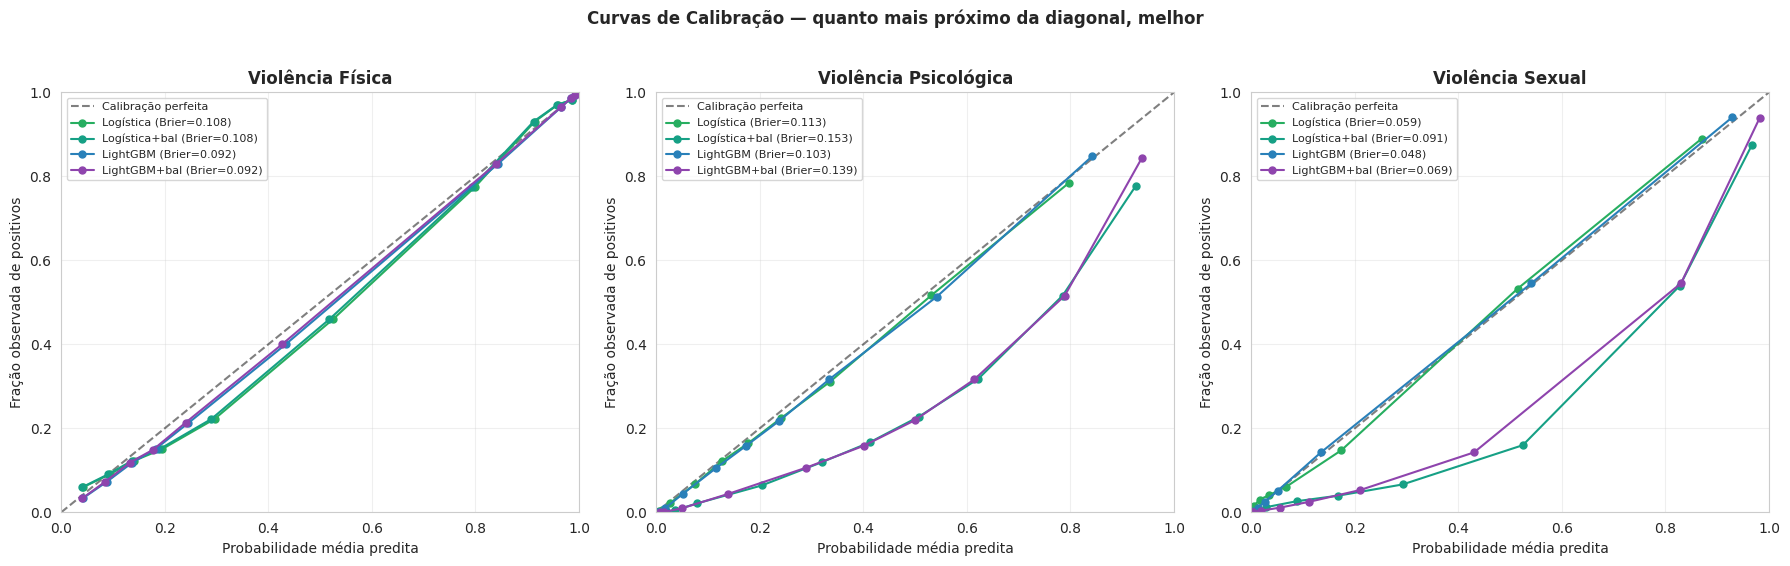

In [25]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for ax, alvo in zip(axes, ALVOS):
    mask = y_test[alvo].notna()
    Xte = X_test[mask.values]
    yte = y_test.loc[mask, alvo].astype(int)

    # Diagonal de referência
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Calibração perfeita')

    for nome, modelo, cor in [
        ('Logística',     log_models[(alvo, False)],        '#27ae60'),
        ('Logística+bal', log_models[(alvo, True)],         '#16a085'),
        ('LightGBM',      nl_models[(alvo, 'lgbm', False)],  '#2980b9'),
        ('LightGBM+bal',  nl_models[(alvo, 'lgbm', True)],   '#8e44ad'),
    ]:
        proba = modelo.predict_proba(Xte)[:, 1]
        frac_pos, mean_pred = calibration_curve(yte, proba, n_bins=10, strategy='quantile')
        brier = brier_score_loss(yte, proba)
        ax.plot(mean_pred, frac_pos, 'o-', color=cor, markersize=5,
                label=f'{nome} (Brier={brier:.3f})')

    ax.set_xlabel('Probabilidade média predita')
    ax.set_ylabel('Fração observada de positivos')
    ax.set_title(f'{NOMES[alvo]}', fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.grid(alpha=0.3)

plt.suptitle('Curvas de Calibração — quanto mais próximo da diagonal, melhor',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTADOS / 'curvas_calibracao.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Efeito do balanceamento na calibração

Brier score com e sem `class_weight='balanced'`.

In [30]:
print('EFEITO DO BALANCEAMENTO SOBRE A CALIBRAÇÃO (Brier score)\n')
print('Brier menor = probabilidades melhor calibradas\n')

for alvo in ALVOS:
    print(f'{NOMES[alvo]}:')
    for base in ['Logística', 'LightGBM']:
        b_sem = df_painel[(df_painel['alvo']==alvo) &
                          (df_painel['modelo']==base)]['brier'].iloc[0]
        b_com = df_painel[(df_painel['alvo']==alvo) &
                          (df_painel['modelo']==f'{base}+bal')]['brier'].iloc[0]
        piora = b_com - b_sem
        print(f'  {base:12} sem balanceamento: {b_sem:.4f}  |  '
              f'com: {b_com:.4f}  |  Δ = {piora:+.4f}')
    print()

EFEITO DO BALANCEAMENTO SOBRE A CALIBRAÇÃO (Brier score)

Brier menor = probabilidades melhor calibradas

Violência Física:
  Logística    sem balanceamento: 0.1078  |  com: 0.1076  |  Δ = -0.0003
  LightGBM     sem balanceamento: 0.0918  |  com: 0.0917  |  Δ = -0.0001

Violência Psicológica:
  Logística    sem balanceamento: 0.1129  |  com: 0.1527  |  Δ = +0.0399
  LightGBM     sem balanceamento: 0.1028  |  com: 0.1389  |  Δ = +0.0362

Violência Sexual:
  Logística    sem balanceamento: 0.0589  |  com: 0.0912  |  Δ = +0.0323
  LightGBM     sem balanceamento: 0.0476  |  com: 0.0692  |  Δ = +0.0215



### 4.5 Recalibração

Regressão isotônica sobre o modelo balanceado, caso se precise de probabilidades confiáveis.

In [27]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Demonstração: recalibração isotônica do LightGBM balanceado
alvo_demo = 'y_fisic'
mask = y_am[alvo_demo].notna()
Xtr = X_am[mask.values]
ytr = y_am.loc[mask, alvo_demo].astype(int)

modelo_base = nl_models[(alvo_demo, 'lgbm', True)]

# CalibratedClassifierCV recalibra usando validação cruzada
try:
    calibrado = CalibratedClassifierCV(FrozenEstimator(modelo_base), method='isotonic')
    calibrado.fit(Xtr, ytr)
    metodo_ok = True
except Exception:
    # Compatibilidade com versões anteriores do sklearn
    calibrado = CalibratedClassifierCV(modelo_base, method='isotonic', cv='prefit')
    calibrado.fit(Xtr, ytr)
    metodo_ok = True

# Compara Brier antes/depois
mask_te = y_test[alvo_demo].notna()
Xte = X_test[mask_te.values]
yte = y_test.loc[mask_te, alvo_demo].astype(int)

brier_antes  = brier_score_loss(yte, modelo_base.predict_proba(Xte)[:,1])
brier_depois = brier_score_loss(yte, calibrado.predict_proba(Xte)[:,1])

print(f'Recalibração isotônica — {NOMES[alvo_demo]}, LightGBM balanceado:\n')
print(f'  Brier antes da recalibração:  {brier_antes:.4f}')
print(f'  Brier após a recalibração:    {brier_depois:.4f}')
print(f'  Melhora: {brier_antes - brier_depois:+.4f}')
print(f'\nA recalibração é um passo recomendado caso o modelo venha a')
print(f'ser usado para estimar probabilidades, não apenas para ordenar.')

Recalibração isotônica — Violência Física, LightGBM balanceado:

  Brier antes da recalibração:  0.0917
  Brier após a recalibração:    0.0920
  Melhora: -0.0003

A recalibração é um passo recomendado caso o modelo venha a
ser usado para estimar probabilidades, não apenas para ordenar.


## 5. Interpretabilidade e robustez

### 5.1 Importância por paradigma

Logística (coeficientes) e LightGBM (ganho) apontam variáveis relevantes. A Logística capta efeitos lineares principais; o LightGBM, interações — baixa sobreposição é esperada, os modelos são complementares.

In [28]:
def importancia_comparada(alvo, top_n=15):
    # Logística: |coeficiente|
    coefs = np.abs(log_models[(alvo, False)].coef_[0])
    top_log = set(np.argsort(coefs)[::-1][:top_n])

    # LightGBM: feature_importances_
    imp = nl_models[(alvo, 'lgbm', False)].feature_importances_
    top_lgbm = set(np.argsort(imp)[::-1][:top_n])

    convergem = top_log & top_lgbm
    return len(convergem), convergem, top_log, top_lgbm

print('CONVERGÊNCIA ENTRE LOGÍSTICA E LIGHTGBM (top 15 variáveis)\n')
for alvo in ALVOS:
    n_conv, conv, _, _ = importancia_comparada(alvo)
    print(f'{NOMES[alvo]}: {n_conv}/15 variáveis em comum ({100*n_conv/15:.0f}%)')
    for idx in sorted(conv):
        print(f'    · {feature_names[idx].replace("cat__","").replace("num__","")[:50]}')
    print()

print('Alta convergência → as principais variáveis são robustas,')
print('detectadas independentemente do paradigma de modelagem.')

CONVERGÊNCIA ENTRE LOGÍSTICA E LIGHTGBM (top 15 variáveis)

Violência Física: 3/15 variáveis em comum (20%)
    · AG_FORCA_1
    · AUTOR_SEXO_1
    · LES_AUTOP_1

Violência Psicológica: 1/15 variáveis em comum (7%)
    · AG_AMEACA_1

Violência Sexual: 1/15 variáveis em comum (7%)
    · AUTOR_SEXO_1

Alta convergência → as principais variáveis são robustas,
detectadas independentemente do paradigma de modelagem.


### 5.2 Estabilidade via bootstrap

Re-treino em reamostragens para verificar se os coeficientes são estáveis.

In [29]:
def estabilidade_bootstrap(alvo, n_boot=20, top_n=10):
    """Re-treina a Logística em reamostragens e mede a variação dos coefs."""
    mask = y_am[alvo].notna()
    Xtr = X_am[mask.values]
    ytr = y_am.loc[mask, alvo].astype(int).values
    n = len(ytr)

    # Features de interesse: top por |coef| do modelo principal
    top_idx = np.argsort(np.abs(log_models[(alvo,False)].coef_[0]))[::-1][:top_n]

    coefs_boot = []
    for b in range(n_boot):
        idx = np.random.RandomState(b).choice(n, size=n, replace=True)
        m = LogisticRegression(max_iter=500, random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(Xtr[idx], ytr[idx])
        coefs_boot.append(m.coef_[0][top_idx])

    coefs_boot = np.array(coefs_boot)
    return top_idx, coefs_boot

print('ESTABILIDADE DOS COEFICIENTES VIA BOOTSTRAP (20 reamostragens)\n')
for alvo in ALVOS:
    print(f'{NOMES[alvo]}:')
    top_idx, coefs_boot = estabilidade_bootstrap(alvo)
    media = coefs_boot.mean(axis=0)
    desvio = coefs_boot.std(axis=0)
    cv = np.abs(desvio / media)  # coeficiente de variação

    for i, idx in enumerate(top_idx):
        nome = feature_names[idx].replace('cat__','').replace('num__','')[:38]
        estavel = 'estável' if cv[i] < 0.15 else ('moderada' if cv[i] < 0.30 else 'INSTÁVEL')
        # Verifica se o sinal é consistente
        sinais = np.sign(coefs_boot[:, i])
        sinal_consistente = (np.abs(sinais.sum()) == len(sinais))
        flag_sinal = '' if sinal_consistente else '  ⚠ sinal inverte!'
        print(f'  {nome:40} coef={media[i]:+.3f}  CV={cv[i]:.2f} ({estavel}){flag_sinal}')
    print()

print('CV = coeficiente de variação. CV<0.15 indica efeito estável.')
print('Inversão de sinal entre reamostragens é sinal de alerta —')
print('o efeito não é confiável, possivelmente por multicolinearidade.')

ESTABILIDADE DOS COEFICIENTES VIA BOOTSTRAP (20 reamostragens)

Violência Física:
  AG_FORCA_1                               coef=+2.281  CV=0.01 (estável)
  AG_FOGO_1                                coef=+1.733  CV=0.04 (estável)
  AG_OBJETO_1                              coef=+1.720  CV=0.03 (estável)
  REL_PAD_                                 coef=-0.262  CV=0.25 (moderada)
  REL_DESCO_                               coef=-0.389  CV=0.19 (moderada)
  REL_CONHEC_                              coef=-0.318  CV=0.27 (moderada)
  REL_CONJ_1                               coef=+1.129  CV=0.05 (estável)
  REL_MAE_                                 coef=+0.411  CV=0.18 (moderada)
  AG_ENFOR_1                               coef=+1.083  CV=0.06 (estável)
  AG_CORTE_1                               coef=+1.085  CV=0.05 (estável)

Violência Psicológica:
  LES_AUTOP_1                              coef=-1.868  CV=0.02 (estável)
  REL_MAE_                                 coef=+0.440  CV=0.28 (moderada)
 